# 2025 Final Holdout Test

## tl;dr

The locked combined model was refit on 2021–2024 and evaluated once on 1,414
eligible 2025 WR appearances.

- The five-game PPR baseline had the best primary MAE: `4.607`.
- The locked combined model had slightly worse MAE: `4.623`.
- The locked combined model had better RMSE (`6.172` versus `6.368`) and R²
  (`0.330` versus `0.287`).

The primary hypothesis was **not supported** on the untouched test season.
Recent opportunity features helped reduce larger misses, but they did not
improve the average absolute prediction error.

## Context & Methods

### Locked decision

Before opening 2025, the model was fixed to use:

- five-game target share
- five-game air-yard share
- five-game PPR average

Mean absolute error (MAE) was preregistered as the primary selection metric.
Lower is better. RMSE and R² are secondary diagnostic metrics.

### Data split

- Final training: 2021–2024
- Final test: 2025
- Eligibility: five previous same-season appearances

No features, filters, models, or thresholds were changed after viewing 2025.
The 2025 holdout is now spent and cannot be described as untouched again.

## Data

### 1. Load the final training and test populations

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "wr_weekly_features.csv"
FIGURE_PATH = PROJECT_ROOT / "reports" / "figures" / "final_test_errors.svg"

all_weeks = pd.read_csv(DATA_PATH, low_memory=False)
eligible_weeks = all_weeks.loc[all_weeks["rolling_5_target_share"].notna()].copy()
training = eligible_weeks.loc[eligible_weeks["season"].between(2021, 2024)].copy()
final_test = eligible_weeks.loc[eligible_weeks["season"].eq(2025)].copy()

print(f"Final training appearances: {len(training):,}")
print(f"Final test appearances: {len(final_test):,}")
assert training["season"].max() == 2024
assert final_test["season"].nunique() == 1
assert final_test["season"].iloc[0] == 2025

Final training appearances: 5,575
Final test appearances: 1,414


## Results

### 2. Refit the locked model and predeclared comparisons

In [2]:
def fit_linear_model(feature_columns):
    training_matrix = np.column_stack(
        [np.ones(len(training)), training[feature_columns].to_numpy(float)]
    )
    coefficients = np.linalg.lstsq(
        training_matrix,
        training["fantasy_points_ppr"].to_numpy(float),
        rcond=None,
    )[0]
    test_matrix = np.column_stack(
        [np.ones(len(final_test)), final_test[feature_columns].to_numpy(float)]
    )
    return test_matrix @ coefficients


predictions = {
    "Five-game PPR baseline": final_test["rolling_5_fantasy_points_ppr"].to_numpy(float),
    "Target share only": fit_linear_model(["rolling_5_target_share"]),
    "Target + air-yard share": fit_linear_model(
        ["rolling_5_target_share", "rolling_5_air_yards_share"]
    ),
    "Locked combined model": fit_linear_model(
        [
            "rolling_5_target_share",
            "rolling_5_air_yards_share",
            "rolling_5_fantasy_points_ppr",
        ]
    ),
}

### 3. Calculate final-test metrics

In [3]:
actual = final_test["fantasy_points_ppr"].to_numpy(float)
total_squared_error = np.sum((actual - actual.mean()) ** 2)
metric_rows = []

for model_name, prediction in predictions.items():
    residual = actual - prediction
    metric_rows.append(
        {
            "model": model_name,
            "MAE": np.mean(np.abs(residual)),
            "RMSE": np.sqrt(np.mean(residual**2)),
            "R_squared": 1 - (np.sum(residual**2) / total_squared_error),
        }
    )

final_metrics = pd.DataFrame(metric_rows).sort_values("MAE").reset_index(drop=True)
print(final_metrics.round({"MAE": 3, "RMSE": 3, "R_squared": 3}).to_string(index=False))

                  model   MAE  RMSE  R_squared
 Five-game PPR baseline 4.607 6.368      0.287
  Locked combined model 4.623 6.172      0.330
      Target share only 4.718 6.275      0.308
Target + air-yard share 4.719 6.275      0.308


### 4. Compare MAE and RMSE

C:\Users\Brecken\Documents\Codex\2026-07-22\hi\outputs\fantasy-football-wr-analytics\reports\figures\final_test_errors.svg


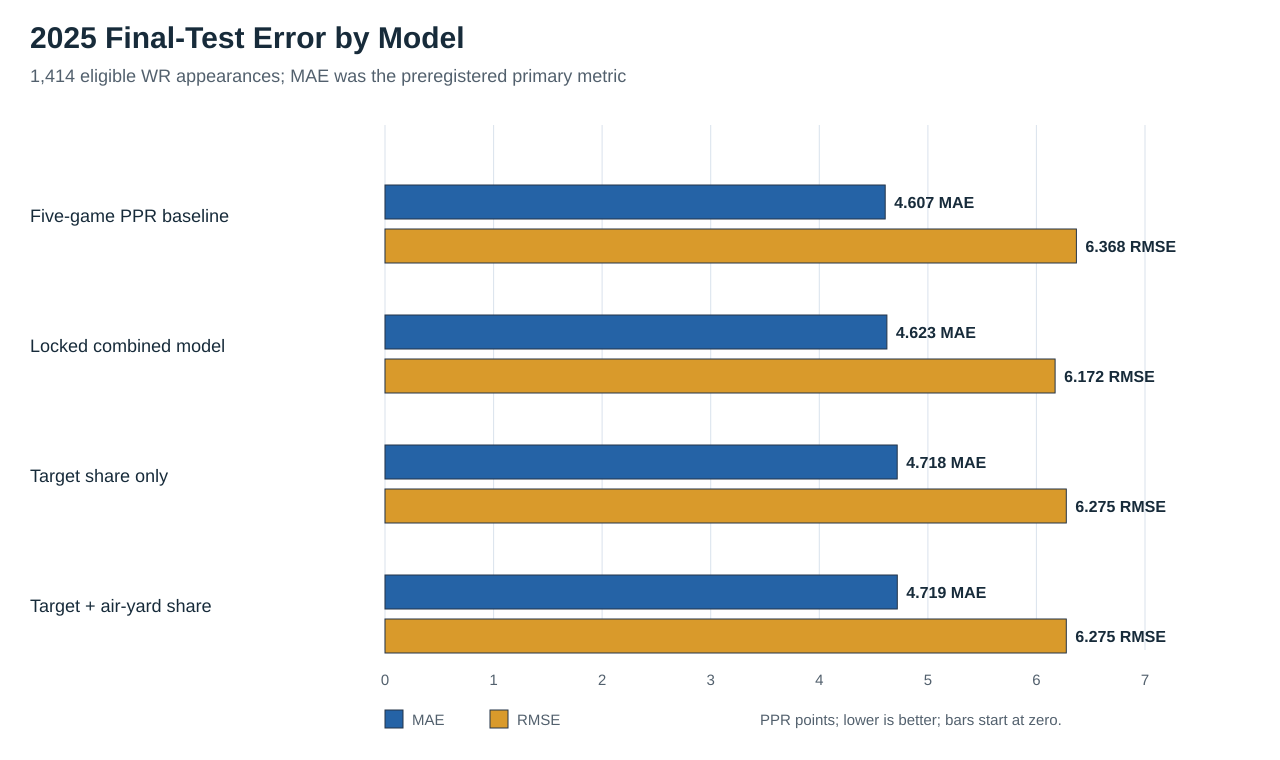

In [4]:
chart_data = final_metrics.sort_values("MAE", ascending=True).reset_index(drop=True)
width, height = 1280, 760
left, top, chart_width = 385, 160, 760
group_y = [185, 315, 445, 575]
scale_max = 7.0

svg = [
    f'<svg xmlns="http://www.w3.org/2000/svg" width="{width}" height="{height}" viewBox="0 0 {width} {height}">',
    '<rect width="100%" height="100%" fill="#ffffff"/>',
    '<style>text{font-family:Arial,sans-serif;fill:#172B3A}.title{font-size:30px;font-weight:700}.subtitle{font-size:18px;fill:#52606D}.label{font-size:18px}.value{font-size:16px;font-weight:700}.note{font-size:15px;fill:#52606D}.axis{font-size:15px;fill:#52606D}</style>',
    '<text x="30" y="48" class="title">2025 Final-Test Error by Model</text>',
    f'<text x="30" y="82" class="subtitle">1,414 eligible WR appearances; MAE was the preregistered primary metric</text>',
]

for tick in range(0, 8):
    x = left + (tick / scale_max) * chart_width
    svg.append(f'<line x1="{x:.1f}" y1="125" x2="{x:.1f}" y2="650" stroke="#D9E2EC" stroke-width="1"/>')
    svg.append(f'<text x="{x:.1f}" y="685" text-anchor="middle" class="axis">{tick}</text>')

for row_index, row in chart_data.iterrows():
    y = group_y[row_index]
    mae_width = (row["MAE"] / scale_max) * chart_width
    rmse_width = (row["RMSE"] / scale_max) * chart_width
    svg.extend(
        [
            f'<text x="30" y="{y + 37}" class="label">{row["model"]}</text>',
            f'<rect x="{left}" y="{y}" width="{mae_width:.1f}" height="34" fill="#2563A6" stroke="#243447"/>',
            f'<text x="{left + mae_width + 9:.1f}" y="{y + 23}" class="value">{row["MAE"]:.3f} MAE</text>',
            f'<rect x="{left}" y="{y + 44}" width="{rmse_width:.1f}" height="34" fill="#D99A2B" stroke="#243447"/>',
            f'<text x="{left + rmse_width + 9:.1f}" y="{y + 67}" class="value">{row["RMSE"]:.3f} RMSE</text>',
        ]
    )

svg.extend(
    [
        '<rect x="385" y="710" width="18" height="18" fill="#2563A6" stroke="#243447"/><text x="412" y="725" class="axis">MAE</text>',
        '<rect x="490" y="710" width="18" height="18" fill="#D99A2B" stroke="#243447"/><text x="517" y="725" class="axis">RMSE</text>',
        '<text x="760" y="725" class="note">PPR points; lower is better; bars start at zero.</text>',
        "</svg>",
    ]
)

FIGURE_PATH.parent.mkdir(parents=True, exist_ok=True)
FIGURE_PATH.write_text("\n".join(svg), encoding="utf-8")
print(FIGURE_PATH)

## Takeaways

- The simple five-game PPR baseline won on the preregistered primary metric.
- The locked combined model missed the baseline by only `0.015` PPR points of
  MAE, approximately `0.3%`.
- The combined model reduced RMSE by `0.196` points, approximately `3.1%`,
  indicating fewer or smaller large errors.
- Target share plus air-yard share again failed to improve MAE meaningfully over
  target share alone.

The honest conclusion is not that the combined model failed entirely. It traded
a tiny amount of typical-error performance for better control of large misses.
However, because MAE was selected in advance, the simple five-game PPR baseline
is the primary winner.